In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)

DATA_PATH = r"/Users/archith25/Desktop/hackathon/Reid Library/reid_library_sensor_data.csv"

df = pd.read_csv(DATA_PATH)

# Removes the unnamed index column included in the CSV export
df = df.loc[:, ~df.columns.str.contains(r"^Unnamed")]

df.head()

,timestamp,power_kw,airflow_m3s,water_pressure_kpa,water_flow_lps,temperature_c,vibration_level,sound_event,system_status,sensor_source
0,2026-07-01 00:00:00,49.391,4.674,361.114,2.310,19.389,0.130,normal,stable,original
1,2026-07-01 01:00:00,47.613,4.452,372.913,2.239,18.724,0.146,normal,stable,original
2,2026-07-01 02:00:00,49.814,4.727,333.217,2.109,18.591,0.126,normal,stable,original
3,2026-07-01 03:00:00,52.264,5.033,356.756,2.003,18.998,0.141,normal,stable,original
4,2026-07-01 04:00:00,47.344,4.418,342.192,2.205,18.915,0.093,normal,stable,original


In [5]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nColumn data types and non-empty values:")
df.info()

print("\nSummary statistics:")
display(df.describe(include="all").T)

Number of rows: 500
Number of columns: 10

Column names:
['timestamp', 'power_kw', 'airflow_m3s', 'water_pressure_kpa', 'water_flow_lps', 'temperature_c', 'vibration_level', 'sound_event', 'system_status', 'sensor_source']

Column data types and non-empty values:
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   timestamp           500 non-null    str    
 1   power_kw            500 non-null    float64
 2   airflow_m3s         498 non-null    float64
 3   water_pressure_kpa  498 non-null    float64
 4   water_flow_lps      499 non-null    float64
 5   temperature_c       500 non-null    float64
 6   vibration_level     499 non-null    float64
 7   sound_event         500 non-null    str    
 8   system_status       500 non-null    str    
 9   sensor_source       500 non-null    str    
dtypes: float64(6), str(4)
memory usage: 39.2 KB

Summ

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
timestamp,500,500,2026-07-01 00:00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
power_kw,500.0,NaN,NaN,NaN,47.251142,4.353444,27.658,45.731,47.8385,49.745,58.788
airflow_m3s,498.0,NaN,NaN,NaN,4.300432,0.632033,1.957,4.09775,4.4245,4.69075,5.848
water_pressure_kpa,498.0,NaN,NaN,NaN,326.981438,70.530143,58.806,337.69775,348.8515,357.592,381.611
water_flow_lps,499.0,NaN,NaN,NaN,1.968854,0.48607,0.094,1.9545,2.093,2.2055,2.54
temperature_c,500.0,NaN,NaN,NaN,18.824592,0.982474,14.126,18.639,18.9775,19.3155,20.597
vibration_level,499.0,NaN,NaN,NaN,0.247054,0.214017,0.059,0.139,0.164,0.2485,1.131
sound_event,500,3,normal,368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
system_status,500,4,stable,368,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sensor_source,500,2,original,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

status_order = ["stable", "warning", "critical", "failed", "recovering"]
sound_order = ["normal", "hum", "rattle"]

df["system_status"] = pd.Categorical(
    df["system_status"],
    categories=status_order,
    ordered=True
)

df["sound_event"] = pd.Categorical(
    df["sound_event"],
    categories=sound_order,
    ordered=True
)

print("Dataset time period:")
print(df["timestamp"].min(), "to", df["timestamp"].max())

print("\nReadings from each sensor source:")
display(df["sensor_source"].value_counts())

print("\nSystem-status counts:")
display(df["system_status"].value_counts().sort_index())

print("\nSound-event counts:")
display(df["sound_event"].value_counts().sort_index())

Dataset time period:
2026-07-01 00:00:00 to 2026-07-21 19:00:00

Readings from each sensor source:


sensor_source
original    450
barry_j_     50
Name: count, dtype: int64


System-status counts:


system_status
stable        368
warning        84
critical       24
failed         24
recovering      0
Name: count, dtype: int64


Sound-event counts:


sound_event
normal    368
hum        84
rattle     48
Name: count, dtype: int64

In [7]:
missing_summary = (
    df.isna()
      .sum()
      .to_frame(name="missing_values")
)

missing_summary["percent_missing"] = (
    missing_summary["missing_values"] / len(df) * 100
).round(2)

display(missing_summary[missing_summary["missing_values"] > 0])

print("Duplicate complete rows:", df.duplicated().sum())
print("Duplicate timestamps:", df["timestamp"].duplicated().sum())

print("\nRows containing missing sensor values:")
display(df[df.isna().any(axis=1)].sort_values("timestamp"))

,missing_values,percent_missing
airflow_m3s,2,0.4
water_pressure_kpa,2,0.4
water_flow_lps,1,0.2
vibration_level,1,0.2


Duplicate complete rows: 0
Duplicate timestamps: 0

Rows containing missing sensor values:


,timestamp,power_kw,airflow_m3s,water_pressure_kpa,water_flow_lps,temperature_c,vibration_level,sound_event,system_status,sensor_source
25,2026-07-02 01:00:00,48.311,NaN,328.341,2.165,19.544,0.156,normal,stable,original
55,2026-07-03 07:00:00,50.608,4.826,NaN,1.999,19.184,0.125,normal,stable,original
85,2026-07-04 13:00:00,46.595,4.324,352.979,2.165,19.347,NaN,normal,stable,original
145,2026-07-07 01:00:00,50.189,4.774,346.727,NaN,19.214,0.195,normal,stable,original
280,2026-07-12 16:00:00,48.318,NaN,352.132,2.120,18.297,0.098,normal,stable,original
415,2026-07-18 07:00:00,45.904,4.238,NaN,2.239,18.729,0.158,normal,stable,original


In [8]:
print([repr(value) for value in df["sensor_source"].unique()])

["'original'", "'barry_j_'"]


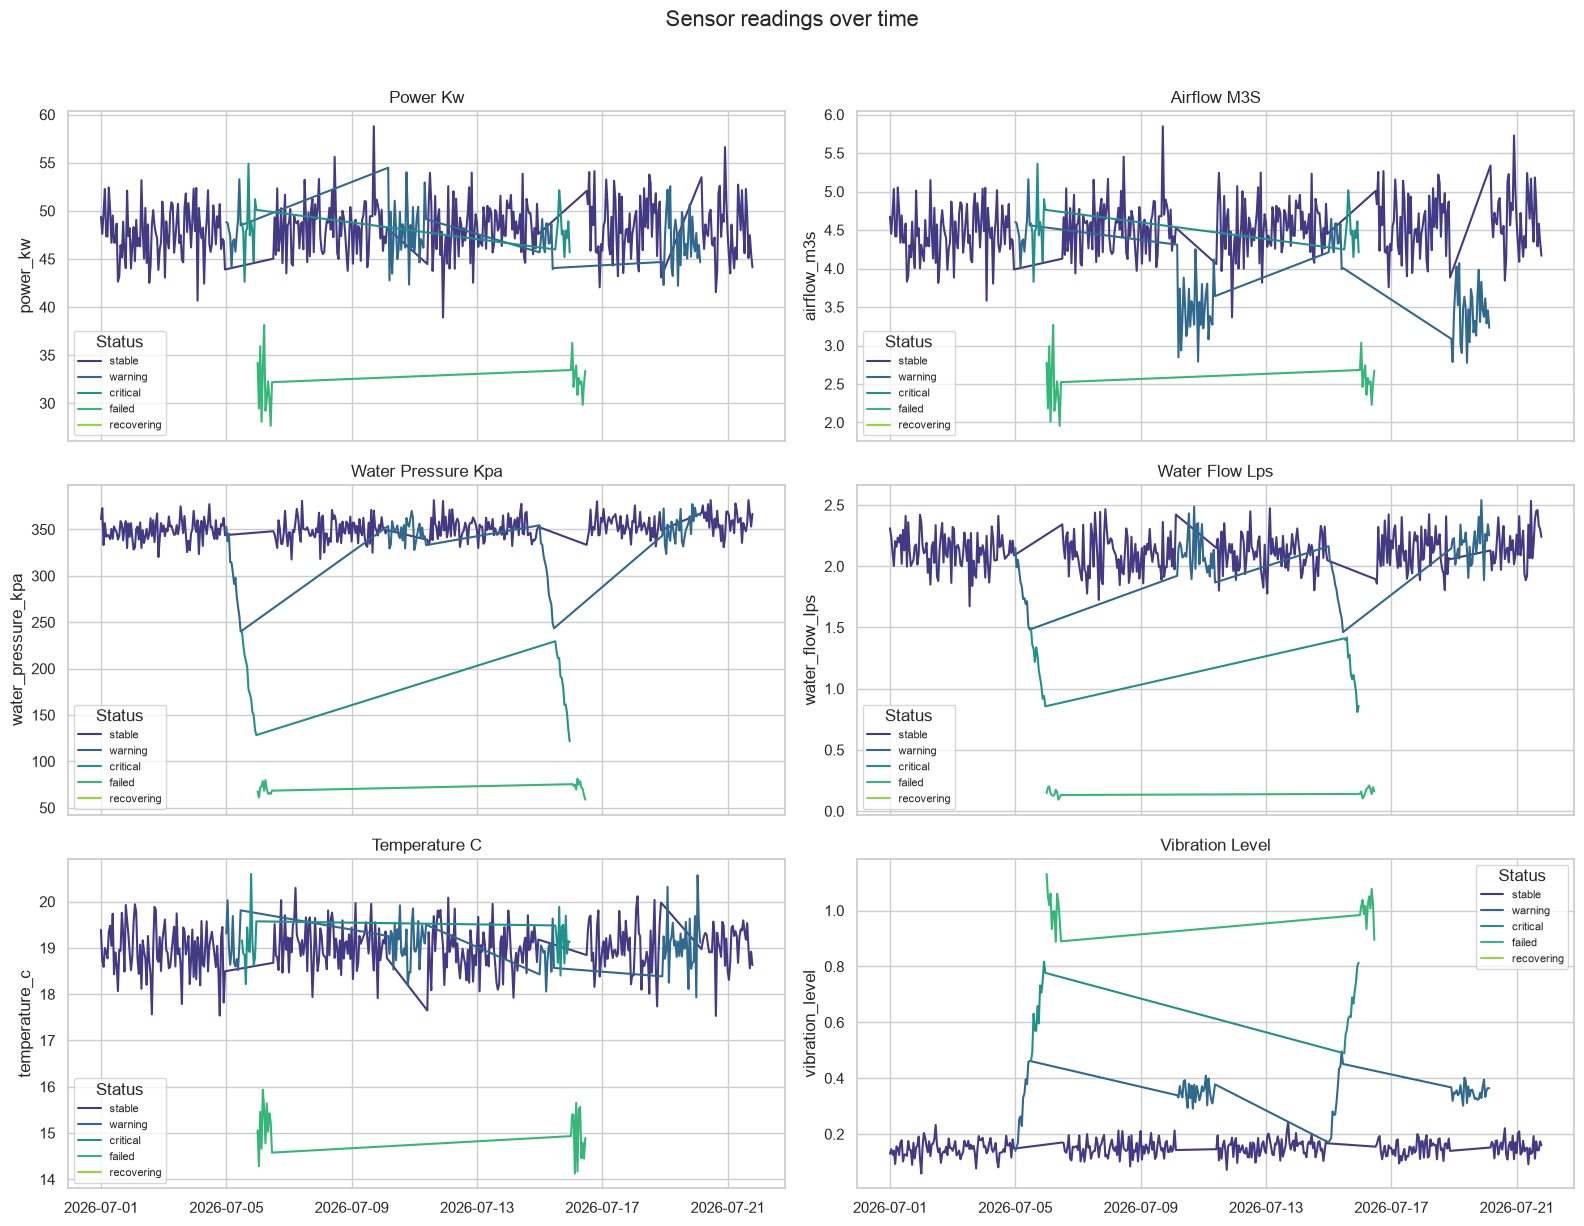

In [9]:
numeric_columns = [
    "power_kw",
    "airflow_m3s",
    "water_pressure_kpa",
    "water_flow_lps",
    "temperature_c",
    "vibration_level",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.lineplot(
        data=df,
        x="timestamp",
        y=column,
        hue="system_status",
        palette="viridis",
        ax=ax
    )
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")
    ax.legend(title="Status", fontsize=8)

plt.suptitle("Sensor readings over time", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_10504/1665192558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_10504/1665192558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_10504/1665192558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_10504/1665192558.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

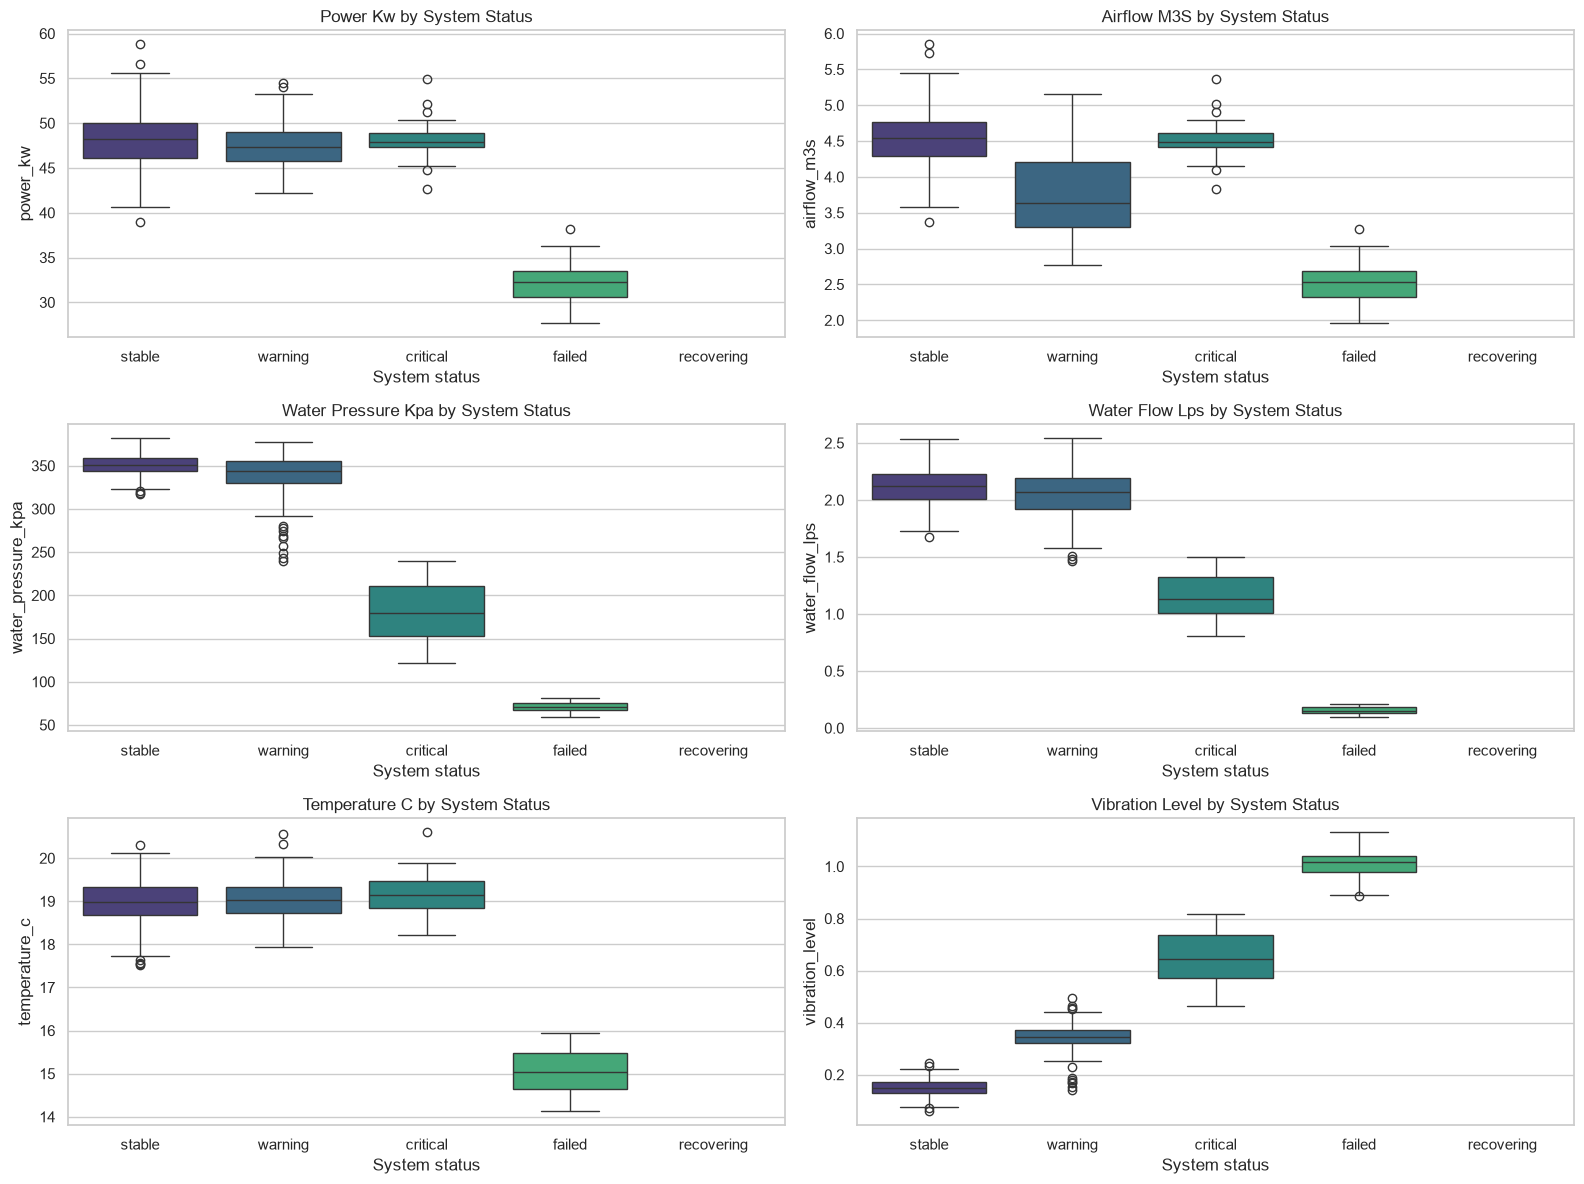

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(
        data=df,
        x="system_status",
        y=column,
        order=status_order,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{column.replace('_', ' ').title()} by System Status")
    ax.set_xlabel("System status")

plt.tight_layout()
plt.show()

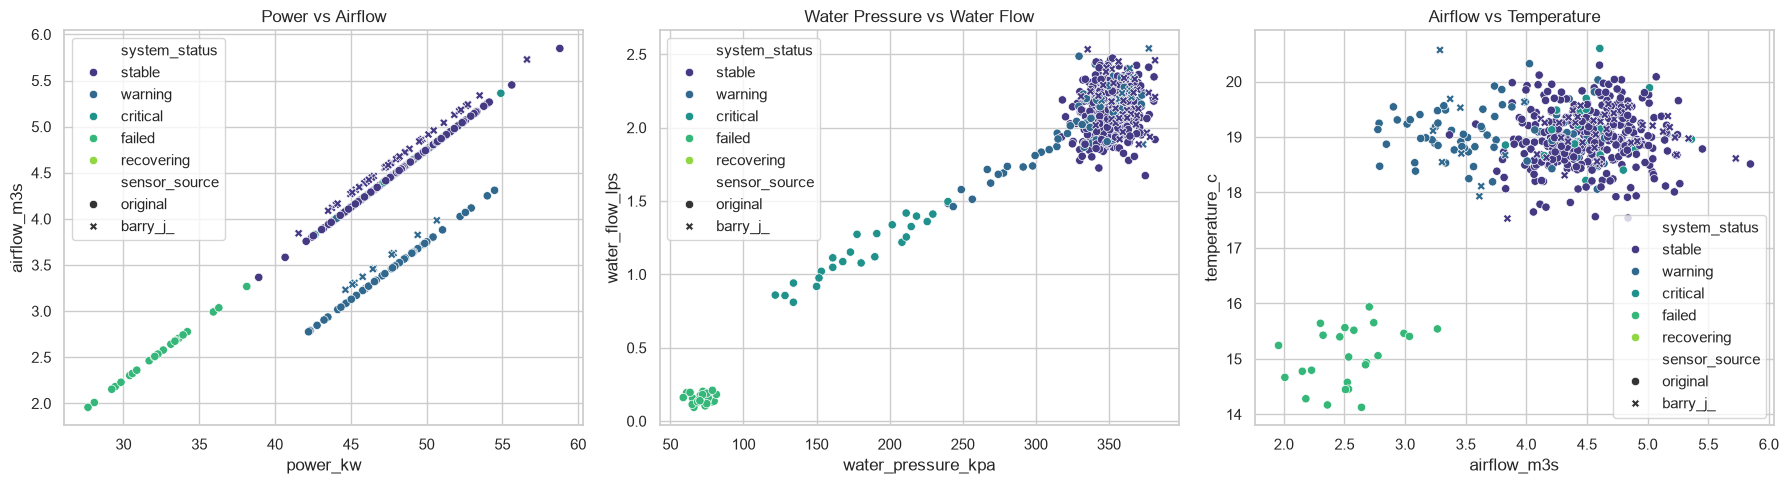

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=df,
    x="power_kw",
    y="airflow_m3s",
    hue="system_status",
    style="sensor_source",
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Power vs Airflow")

sns.scatterplot(
    data=df,
    x="water_pressure_kpa",
    y="water_flow_lps",
    hue="system_status",
    style="sensor_source",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Water Pressure vs Water Flow")

sns.scatterplot(
    data=df,
    x="airflow_m3s",
    y="temperature_c",
    hue="system_status",
    style="sensor_source",
    palette="viridis",
    ax=axes[2]
)
axes[2].set_title("Airflow vs Temperature")

plt.tight_layout()
plt.show()

system_status,stable,warning,critical,failed,recovering
sound_event,,,,,
normal,1.0,0.0,0.0,0.0,NaN
hum,0.0,1.0,0.0,0.0,NaN
rattle,0.0,0.0,0.5,0.5,NaN


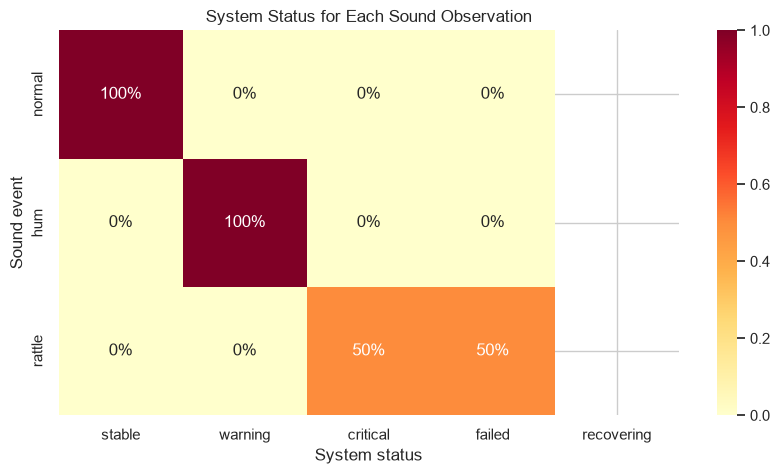

In [12]:
sound_status = pd.crosstab(
    df["sound_event"],
    df["system_status"],
    normalize="index"
).reindex(index=sound_order, columns=status_order)

display(sound_status.round(2))

plt.figure(figsize=(10, 5))
sns.heatmap(sound_status, annot=True, fmt=".0%", cmap="YlOrRd")

plt.title("System Status for Each Sound Observation")
plt.xlabel("System status")
plt.ylabel("Sound event")
plt.show()

In [13]:
# Make a cleaned copy; keep df unchanged
df_clean = df.copy().sort_values("timestamp").set_index("timestamp")

sensor_columns = [
    "airflow_m3s",
    "water_pressure_kpa",
    "water_flow_lps",
    "vibration_level",
]

# Create flags that record which values were originally missing
for column in sensor_columns:
    df_clean[f"{column}_was_missing"] = df_clean[column].isna().astype(int)

# Fill isolated internal gaps using readings before and after each timestamp
df_clean[sensor_columns] = df_clean[sensor_columns].interpolate(
    method="time",
    limit=1,
    limit_area="inside"
)

# Return timestamp to a regular column
df_clean = df_clean.reset_index()

# Confirm there are no remaining missing sensor values
display(df_clean[sensor_columns].isna().sum())

# Display the estimated rows and the relevant missing-value flags
estimated_rows = df_clean[
    df_clean[[f"{column}_was_missing" for column in sensor_columns]].any(axis=1)
]

display(estimated_rows)

airflow_m3s           0
water_pressure_kpa    0
water_flow_lps        0
vibration_level       0
dtype: int64

,timestamp,power_kw,airflow_m3s,water_pressure_kpa,water_flow_lps,temperature_c,vibration_level,sound_event,system_status,sensor_source,airflow_m3s_was_missing,water_pressure_kpa_was_missing,water_flow_lps_was_missing,vibration_level_was_missing
25,2026-07-02 01:00:00,48.311,4.2030,328.3410,2.165,19.544,0.156,normal,stable,original,1,0,0,0
55,2026-07-03 07:00:00,50.608,4.8260,349.1000,1.999,19.184,0.125,normal,stable,original,0,1,0,0
85,2026-07-04 13:00:00,46.595,4.3240,352.9790,2.165,19.347,0.134,normal,stable,original,0,0,0,1
145,2026-07-07 01:00:00,50.189,4.7740,346.7270,2.005,19.214,0.195,normal,stable,original,0,0,1,0
280,2026-07-12 16:00:00,48.318,4.5485,352.1320,2.120,18.297,0.098,normal,stable,original,1,0,0,0
415,2026-07-18 07:00:00,45.904,4.2380,353.0755,2.239,18.729,0.158,normal,stable,original,0,1,0,0


In [14]:
# Use the cleaned dataset from Step 1
# If you restarted the notebook, run the Step 1 loading and cleaning cells first.

numeric_columns = [
    "power_kw",
    "airflow_m3s",
    "water_pressure_kpa",
    "water_flow_lps",
    "temperature_c",
    "vibration_level",
]

# Ensure source labels have no accidental spaces
df_clean["sensor_source"] = df_clean["sensor_source"].astype(str).str.strip()

print(df_clean["sensor_source"].value_counts())

# Compare only stable readings: this avoids comparing fault states with normal states
stable_readings = df_clean[df_clean["system_status"] == "stable"].copy()

sensor_medians = (
    stable_readings
    .groupby("sensor_source")[numeric_columns]
    .median()
    .T
)

display(sensor_medians)

sensor_source
original    450
barry_j_     50
Name: count, dtype: int64


sensor_source,barry_j_,original
power_kw,47.6635,48.2645
airflow_m3s,4.6080,4.5310
water_pressure_kpa,359.4725,350.2805
water_flow_lps,2.1650,2.1120
temperature_c,19.1900,18.9815
vibration_level,0.1510,0.1500


In [ ]:
original_source = "original"
barry_source = [source for source in df_clean["sensor_source"].unique() if source != original_source][0]

offsets = pd.DataFrame({
    "original_median": sensor_medians[original_source],
    "barry_median": sensor_medians[barry_source],
})

# Absolute difference (Barry - Original)
offsets["barry_minus_original"] = (
    offsets["barry_median"] - offsets["original_median"]
).round(3)

# Percentage change from original to Barry J (positive = increase)
offsets["percent_change"] = (
    (offsets["barry_median"] - offsets["original_median"]) /
    offsets["original_median"] * 100
).replace([np.inf, -np.inf], np.nan).round(2)

display(offsets)

,original_median,barry_median,barry_minus_original
power_kw,48.2645,47.6635,-0.601
airflow_m3s,4.5310,4.6080,0.077
water_pressure_kpa,350.2805,359.4725,9.192
water_flow_lps,2.1120,2.1650,0.053
temperature_c,18.9815,19.1900,0.208
vibration_level,0.1500,0.1510,0.001


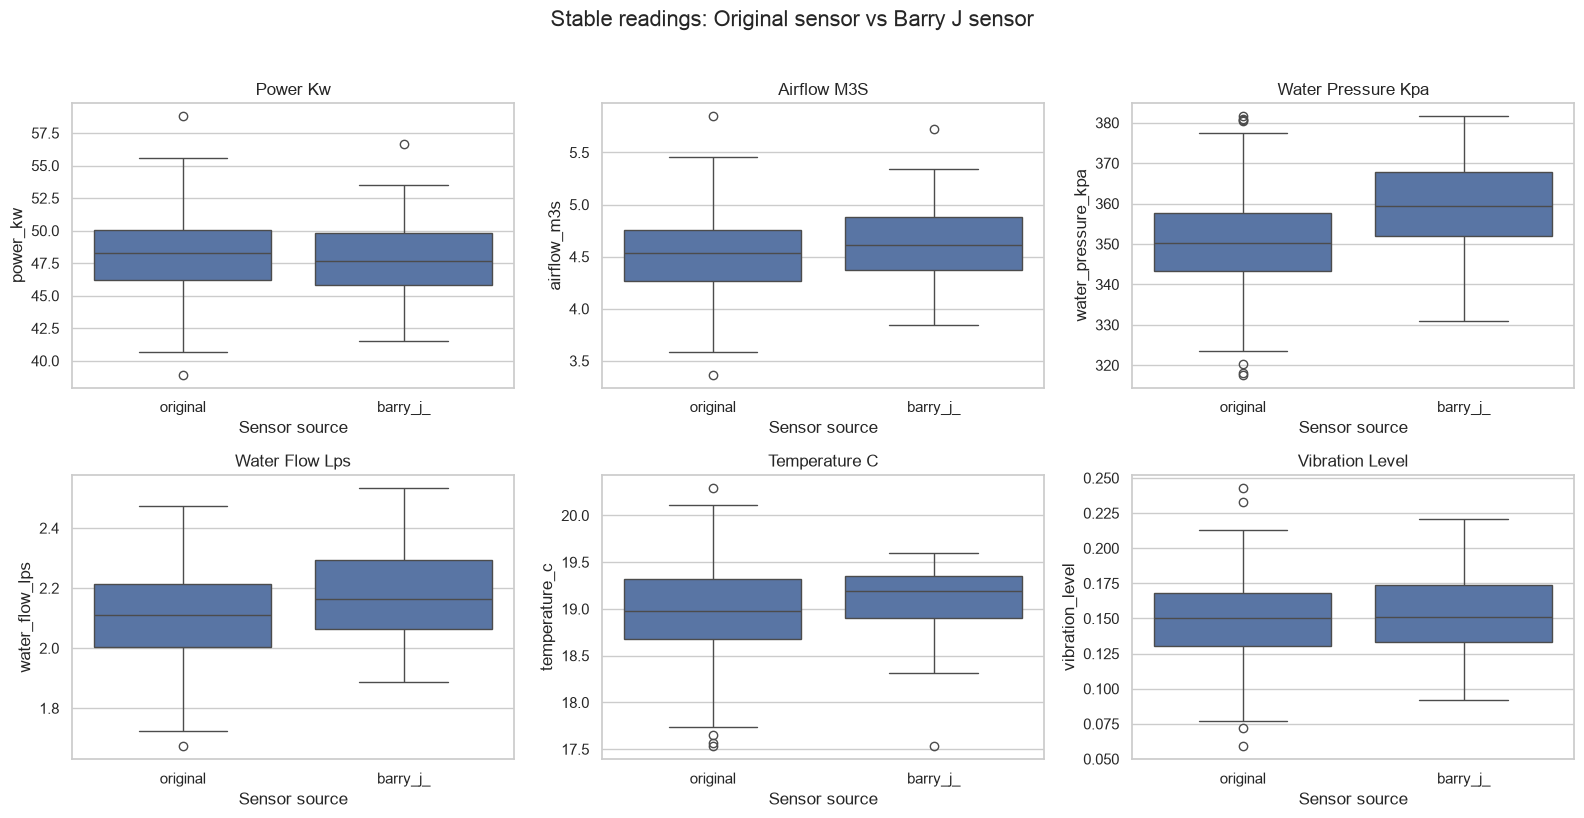

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    sns.boxplot(
        data=stable_readings,
        x="sensor_source",
        y=column,
        ax=ax
    )
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("Sensor source")

plt.suptitle("Stable readings: Original sensor vs Barry J sensor", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
# Create a separate calibrated dataset.
# This preserves df_clean as the pre-calibration dataset.
df_calibrated = df_clean.copy()

# Keep the uncorrected pressure value for auditability
df_calibrated["water_pressure_kpa_raw"] = df_calibrated["water_pressure_kpa"]

# Based on the diagnostic table, Barry J is approximately +10 kPa too high.
PRESSURE_OFFSET_KPA = 10.0

barry_rows = df_calibrated["sensor_source"] == barry_source

df_calibrated.loc[barry_rows, "water_pressure_kpa"] = (
    df_calibrated.loc[barry_rows, "water_pressure_kpa"] - PRESSURE_OFFSET_KPA
)

print(f"Corrected {barry_rows.sum()} Barry J readings by subtracting {PRESSURE_OFFSET_KPA} kPa.")

Corrected 50 Barry J readings by subtracting 10.0 kPa.


In [18]:
validation = (
    df_calibrated[df_calibrated["system_status"] == "stable"]
    .groupby("sensor_source")["water_pressure_kpa"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

display(validation.round(2))

,count,mean,median,std,min,max
sensor_source,,,,,,
barry_j_,40,349.13,349.47,12.33,320.91,371.61
original,328,350.40,350.28,11.60,317.64,381.59


In [19]:
df_analysis = df_calibrated.copy().sort_values("timestamp").reset_index(drop=True)

# A new episode begins whenever the labelled system status changes
df_analysis["status_changed"] = (
    df_analysis["system_status"]
    != df_analysis["system_status"].shift()
)

df_analysis["episode_id"] = df_analysis["status_changed"].cumsum()

episode_summary = (
    df_analysis
    .groupby("episode_id", observed=True)
    .agg(
        start=("timestamp", "first"),
        end=("timestamp", "last"),
        status=("system_status", "first"),
        sound=("sound_event", "first"),
        readings=("timestamp", "size"),
        power_mean=("power_kw", "mean"),
        airflow_mean=("airflow_m3s", "mean"),
        pressure_mean=("water_pressure_kpa", "mean"),
        flow_mean=("water_flow_lps", "mean"),
        temperature_mean=("temperature_c", "mean"),
        vibration_mean=("vibration_level", "mean"),
    )
    .reset_index()
)

episode_summary["duration_hours"] = (
    (episode_summary["end"] - episode_summary["start"])
    .dt.total_seconds()
    .div(3600)
    .add(1)
    .astype(int)
)

display(episode_summary.round(2))

/var/folders/x2/p857nctj7hndgfwnttbcz4jh0000gn/T/ipykernel_10504/390125912.py:38: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(episode_summary.round(2))


,episode_id,start,end,status,sound,readings,power_mean,airflow_mean,pressure_mean,flow_mean,temperature_mean,vibration_mean,duration_hours
0,1,2026-07-01 00:00:00,2026-07-04 23:00:00,stable,normal,96,47.69,4.46,348.77,2.13,18.94,0.15,96
1,2,2026-07-05 00:00:00,2026-07-05 11:00:00,warning,hum,12,47.92,4.49,299.92,1.81,19.08,0.30,12
2,3,2026-07-05 12:00:00,2026-07-05 23:00:00,critical,rattle,12,48.36,4.55,181.26,1.17,19.10,0.65,12
3,4,2026-07-06 00:00:00,2026-07-06 11:00:00,failed,rattle,12,31.82,2.48,69.69,0.15,15.14,1.00,12
4,5,2026-07-06 12:00:00,2026-07-10 03:00:00,stable,normal,88,48.34,4.54,348.78,2.10,19.08,0.15,88
5,6,2026-07-10 04:00:00,2026-07-11 09:00:00,warning,hum,30,47.91,3.49,347.54,2.11,19.10,0.35,30
6,7,2026-07-11 10:00:00,2026-07-14 23:00:00,stable,normal,86,48.22,4.53,351.36,2.11,18.95,0.15,86
7,8,2026-07-15 00:00:00,2026-07-15 11:00:00,warning,hum,12,46.78,4.35,298.75,1.82,18.82,0.32,12
8,9,2026-07-15 12:00:00,2026-07-15 23:00:00,critical,rattle,12,47.93,4.49,180.16,1.15,19.18,0.66,12
9,10,2026-07-16 00:00:00,2026-07-16 11:00:00,failed,rattle,12,32.63,2.58,72.44,0.16,14.95,1.00,12


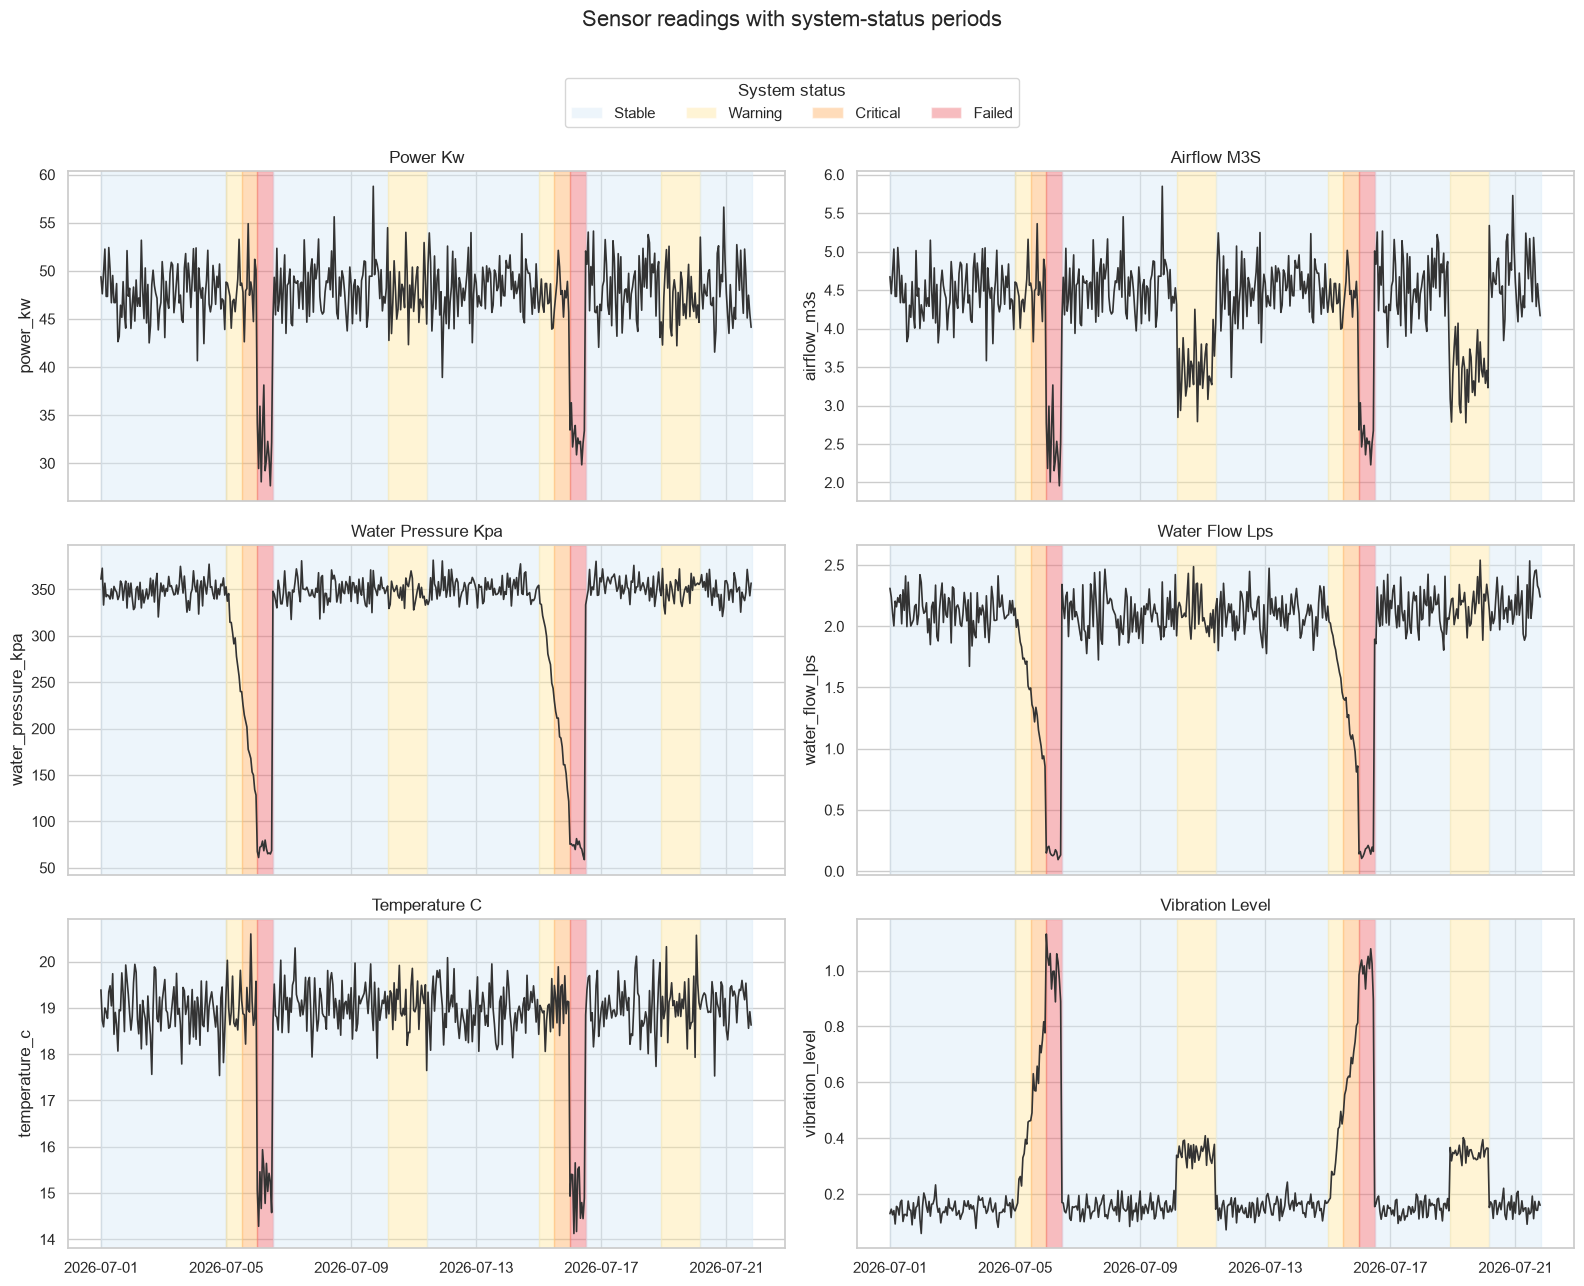

In [20]:
from matplotlib.patches import Patch

status_colors = {
    "stable": "#d9eaf7",
    "warning": "#ffe8a3",
    "critical": "#ffb366",
    "failed": "#ef6b73",
    "recovering": "#9bd69b",
}

numeric_columns = [
    "power_kw",
    "airflow_m3s",
    "water_pressure_kpa",
    "water_flow_lps",
    "temperature_c",
    "vibration_level",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True)
axes = axes.flatten()

for ax, column in zip(axes, numeric_columns):
    # Continuous black line: actual sensor values
    ax.plot(
        df_analysis["timestamp"],
        df_analysis[column],
        color="#333333",
        linewidth=1.2
    )

    # Background shading: labelled system condition
    for _, episode in episode_summary.iterrows():
        end_plus_one_hour = episode["end"] + pd.Timedelta(hours=1)

        ax.axvspan(
            episode["start"],
            end_plus_one_hour,
            color=status_colors[episode["status"]],
            alpha=0.45
        )

    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel(column)

legend_items = [
    Patch(facecolor=colour, alpha=0.45, label=status.title())
    for status, colour in status_colors.items()
    if status in df_analysis["system_status"].astype(str).unique()
]

fig.legend(
    handles=legend_items,
    title="System status",
    loc="upper center",
    ncol=len(legend_items),
    bbox_to_anchor=(0.5, 1.02)
)

plt.suptitle("Sensor readings with system-status periods", fontsize=16, y=1.07)
plt.tight_layout()
plt.show()

In [21]:
# Use stable readings as the normal operating baseline
stable_baseline = df_analysis[df_analysis["system_status"] == "stable"]

baseline_limits = pd.DataFrame({
    "low_alert_threshold": stable_baseline[numeric_columns].quantile(0.05),
    "normal_median": stable_baseline[numeric_columns].median(),
    "high_alert_threshold": stable_baseline[numeric_columns].quantile(0.95),
})

display(baseline_limits.round(3))

,low_alert_threshold,normal_median,high_alert_threshold
power_kw,43.794,48.214,52.525
airflow_m3s,3.991,4.542,5.136
water_pressure_kpa,331.214,350.062,370.273
water_flow_lps,1.885,2.118,2.379
temperature_c,18.194,18.989,19.806
vibration_level,0.104,0.150,0.196


In [22]:
df_alerts = df_analysis.copy()

# Plumbing deterioration:
# low pressure + low water flow + high vibration
df_alerts["plumbing_warning"] = (
    (df_alerts["water_pressure_kpa"] < 320) &
    (df_alerts["water_flow_lps"] < 1.9) &
    (df_alerts["vibration_level"] > 0.25)
)

# Ventilation inefficiency:
# normal electrical power but unusually low airflow + raised vibration
df_alerts["ventilation_warning"] = (
    (df_alerts["power_kw"] > 40) &
    (df_alerts["airflow_m3s"] < 4.0) &
    (df_alerts["vibration_level"] > 0.25)
)

# Severe/failure-level condition:
df_alerts["critical_failure_alert"] = (
    (df_alerts["water_pressure_kpa"] < 100) |
    (df_alerts["water_flow_lps"] < 0.3) |
    (df_alerts["vibration_level"] > 0.85)
)

# One readable final alert for each hourly reading
df_alerts["derived_alert"] = "normal"

df_alerts.loc[
    df_alerts["ventilation_warning"],
    "derived_alert"
] = "ventilation warning"

df_alerts.loc[
    df_alerts["plumbing_warning"],
    "derived_alert"
] = "plumbing warning"

df_alerts.loc[
    df_alerts["critical_failure_alert"],
    "derived_alert"
] = "critical / failure alert"

display(
    df_alerts[
        ["timestamp", "system_status", "sound_event", "derived_alert"]
    ].value_counts().sort_index()
)

timestamp            system_status  sound_event  derived_alert
2026-07-01 00:00:00  stable         normal       normal           1
                                    hum          normal           0
                                    rattle       normal           0
                     warning        normal       normal           0
                                    hum          normal           0
                                                                 ..
2026-07-21 19:00:00  failed         hum          normal           0
                                    rattle       normal           0
                     recovering     normal       normal           0
                                    hum          normal           0
                                    rattle       normal           0
Name: count, Length: 7500, dtype: int64

In [23]:
alert_evaluation = pd.crosstab(
    df_alerts["derived_alert"],
    df_alerts["system_status"],
    margins=True
)

display(alert_evaluation)

system_status,stable,warning,critical,failed,All
derived_alert,,,,,
critical / failure alert,0,0,0,24,24
normal,368,15,0,0,383
plumbing warning,0,14,24,0,38
ventilation warning,0,55,0,0,55
All,368,84,24,24,500


In [24]:
failure_starts = episode_summary[
    episode_summary["status"] == "failed"
]["start"].tolist()

lead_time_results = []

for failure_start in failure_starts:
    # Look back over the 24 hours immediately before failure
    prior_window = df_alerts[
        (df_alerts["timestamp"] >= failure_start - pd.Timedelta(hours=24)) &
        (df_alerts["timestamp"] < failure_start)
    ]

    plumbing_alerts = prior_window[
        prior_window["derived_alert"] == "plumbing warning"
    ]

    first_alert_time = plumbing_alerts["timestamp"].min()

    lead_time_hours = (
        (failure_start - first_alert_time).total_seconds() / 3600
        if pd.notna(first_alert_time)
        else None
    )

    lead_time_results.append({
        "failure_start": failure_start,
        "first_plumbing_alert": first_alert_time,
        "lead_time_hours": lead_time_hours,
    })

lead_time_df = pd.DataFrame(lead_time_results)
display(lead_time_df)

,failure_start,first_plumbing_alert,lead_time_hours
0,2026-07-06,2026-07-05 04:00:00,20.0
1,2026-07-16,2026-07-15 05:00:00,19.0


In [25]:
# An alert is any derived result other than "normal"
df_alerts["alert_raised"] = df_alerts["derived_alert"] != "normal"

# Ground truth: any state other than stable is treated as an abnormal condition
df_alerts["actual_problem"] = df_alerts["system_status"] != "stable"

true_positive = (
    df_alerts["alert_raised"] & df_alerts["actual_problem"]
).sum()

false_positive = (
    df_alerts["alert_raised"] & ~df_alerts["actual_problem"]
).sum()

false_negative = (
    ~df_alerts["alert_raised"] & df_alerts["actual_problem"]
).sum()

true_negative = (
    ~df_alerts["alert_raised"] & ~df_alerts["actual_problem"]
).sum()

precision = true_positive / (true_positive + false_positive)
recall = true_positive / (true_positive + false_negative)
accuracy = (true_positive + true_negative) / len(df_alerts)

performance_summary = pd.DataFrame({
    "metric": [
        "True positives",
        "False positives",
        "False negatives",
        "True negatives",
        "Precision",
        "Recall",
        "Accuracy",
    ],
    "value": [
        true_positive,
        false_positive,
        false_negative,
        true_negative,
        precision,
        recall,
        accuracy,
    ]
})

display(performance_summary)

,metric,value
0,True positives,117.000000
1,False positives,0.000000
2,False negatives,15.000000
3,True negatives,368.000000
4,Precision,1.000000
5,Recall,0.886364
6,Accuracy,0.970000


In [27]:
from pathlib import Path

# Folder where the files will be created
OUTPUT_DIR = Path(
    r"/Users/archith25/Desktop/hackathon/Reid Library/dashboard_export"
)
OUTPUT_DIR.mkdir(exist_ok=True)

# Keep the fields useful for the website.
# water_pressure_kpa is the corrected value.
dashboard_columns = [
    "timestamp",
    "power_kw",
    "airflow_m3s",
    "water_pressure_kpa",
    "water_flow_lps",
    "temperature_c",
    "vibration_level",
    "sound_event",
    "system_status",
    "sensor_source",
    "derived_alert",
    "alert_raised",
]

dashboard_data = df_alerts[dashboard_columns].copy()

# Makes timestamps easy for the website to read
dashboard_data["timestamp"] = pd.to_datetime(
    dashboard_data["timestamp"]
).dt.strftime("%Y-%m-%d %H:%M:%S")

# Marks readings where Barry J pressure was calibrated
dashboard_data["pressure_calibrated"] = (
    dashboard_data["sensor_source"] == barry_source
)

# Main dashboard dataset
dashboard_data.to_csv(
    OUTPUT_DIR / "reid_library_dashboard_data.csv",
    index=False
)

# Useful dashboard summary files
episode_summary.to_csv(
    OUTPUT_DIR / "failure_episode_summary.csv",
    index=False
)

lead_time_df.to_csv(
    OUTPUT_DIR / "failure_warning_lead_times.csv",
    index=False
)

performance_summary.to_csv(
    OUTPUT_DIR / "alert_rule_performance.csv",
    index=False
)

print("Files created:")
for file in OUTPUT_DIR.iterdir():
    print(file.name)

Files created:
reid_library_dashboard_data.csv
failure_episode_summary.csv
failure_warning_lead_times.csv
alert_rule_performance.csv


In [ ]:
# Main Data Processing Methods
"""
This notebook uses the following core data-processing methods:

- `pd.read_csv()` to load the raw sensor data from CSV.
- `.loc[:, ~df.columns.str.contains(r"^Unnamed")]` to drop unwanted unnamed index columns produced by the CSV export.
- `pd.to_datetime()` to convert `timestamp` into a datetime object for time-based operations.
- `pd.Categorical()` to define ordered categories for `system_status` and `sound_event`, which improves sorting and plotting consistency.
- `.isna().sum()` and `.duplicated()` to identify missing values and duplicate data.
- `.copy()` and `.interpolate(method="time", limit=1, limit_area="inside")` to fill isolated missing sensor values while preserving the original dataset and tracking interpolated readings.
- `.groupby(...).median()` for stable-period comparisons and to detect sensor source offsets.
- Boolean masks for rule-based alert creation and derived alert labeling.
- `.shift()` and `.cumsum()` to group continuous runs of the same `system_status` into episodes.
- `pd.crosstab()` and manual count calculations to evaluate alert performance against ground truth labels.
- `.to_csv()` to export cleaned dashboard inputs, episode summaries, lead-time metrics, and alert performance tables for downstream use.

These methods together create a reproducible pipeline from raw data cleaning through calibration, event segmentation, rule-based alerting, and evaluation.
"""